# Notebook 16 — Transformer Inverse Design (A1 MLP + B5)

**Goal**: Train a **Transformer-based** network that, given a 1000-point target absorption
spectrum, predicts 20 design parameters using cross-attention.

| Aspect | Detail |
|--------|--------|
| **Forward surrogate** | A1 MLP (frozen, from Notebook 11) |
| **Inverse method** | Transformer encoder–decoder |
| **Encoder** | Spectrum tokenised → 50 tokens (dim 128), 4-layer TransformerEncoder |
| **Decoder** | 20 learnable queries, 4-layer TransformerDecoder |
| **Loss** | Param MSE + λ·Spectral MSE (through surrogate) |
| **Key advantage** | Attention captures global spectral patterns; DETR-like set prediction |

In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================
import sys, os, time, pickle, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath('../src'))
from Theoretical_model import calculate_acoustic_properties
from physics_guided_CD_FiLM import PARAM_RANGES, validate_and_clip_parameters

assert torch.cuda.is_available(), 'CUDA required'
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f'Device: {torch.cuda.get_device_name()}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Paths
DATA_PATH      = '../data/lhs_data_full_spectrum.npz'
MODEL_DIR      = '../models'
SURROGATE_PATH = os.path.join(MODEL_DIR, 'forward_surrogate_mlp.pth')
TRANS_PATH     = os.path.join(MODEL_DIR, 'inverse_transformer_a1.pth')
TRANS_SCALER   = os.path.join(MODEL_DIR, 'inverse_transformer_a1_scaler.pkl')

# Hyper-parameters
BATCH_SIZE   = 256
EPOCHS       = 50
LR_INIT      = 1e-4      # Transformers prefer lower LR
LR_MIN       = 1e-6
D_MODEL      = 128       # token dim
NHEAD        = 8
NUM_ENC_LAYERS = 4
NUM_DEC_LAYERS = 4
DIM_FF       = 512
DROPOUT      = 0.1
TOKEN_LEN    = 20        # each token = 50 freq bins → 1000/20 = 50 tokens
NUM_TOKENS   = 1000 // TOKEN_LEN  # 50
NUM_QUERIES  = 20        # one per design parameter
LAMBDA_SPEC  = 2.0
NUM_PARAMS   = 20
NUM_FREQ     = 1000
NUM_CANDIDATES = 1       # Transformer is deterministic; no sampling

PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']

print(f'\n  Spectrum → {NUM_TOKENS} tokens of length {TOKEN_LEN}')
print('✓ Imports & config ready')

Device: NVIDIA GeForce RTX 4050 Laptop GPU

  Spectrum → 50 tokens of length 20
✓ Imports & config ready


In [2]:
# ============================================================
# Cell 2 — Load Data & Split
# ============================================================
print('Loading NPZ …')
t0 = time.time()
raw = np.load(DATA_PATH)
params_all  = raw['params'].astype(np.float32)
spectra_all = raw['spectra'].astype(np.float32)
frequencies = raw['frequencies']
print(f'  Loaded in {time.time()-t0:.1f}s')

X_train, X_temp, Y_train, Y_temp = train_test_split(
    params_all, spectra_all, test_size=0.2, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=SEED)

print(f'  Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

scaler_x = MinMaxScaler()
X_train_n = scaler_x.fit_transform(X_train).astype(np.float32)
X_val_n   = scaler_x.transform(X_val).astype(np.float32)
X_test_n  = scaler_x.transform(X_test).astype(np.float32)

def make_loader(spec, params_n, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(spec, dtype=torch.float32),
                       torch.tensor(params_n, dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=True)

train_loader = make_loader(Y_train, X_train_n, BATCH_SIZE)
val_loader   = make_loader(Y_val,   X_val_n,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(Y_test,  X_test_n,  BATCH_SIZE, shuffle=False)
print('✓ Data ready')

Loading NPZ …
  Loaded in 39.1s
  Train: 800,000  Val: 100,000  Test: 100,000
✓ Data ready


In [3]:
# ============================================================
# Cell 3 — Load Forward Surrogate (frozen)
# ============================================================
class ForwardSurrogateMLP(nn.Module):
    def __init__(self, in_dim=20, out_dim=1000, hidden_dim=512, num_layers=4, dropout=0.05):
        super().__init__()
        layers = []
        prev = in_dim
        for _ in range(num_layers):
            layers += [nn.Linear(prev, hidden_dim), nn.BatchNorm1d(hidden_dim),
                       nn.LeakyReLU(0.01, inplace=True), nn.Dropout(dropout)]
            prev = hidden_dim
        layers += [nn.Linear(hidden_dim, out_dim), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

ckpt_surr = torch.load(SURROGATE_PATH, map_location=device, weights_only=False)
arch = ckpt_surr['architecture']
surrogate = ForwardSurrogateMLP(**arch).to(device)
surrogate.load_state_dict(ckpt_surr['model_state_dict'])
surrogate.eval()
for p in surrogate.parameters(): p.requires_grad = False
print(f'✓ Surrogate loaded (MSE={ckpt_surr["test_metrics"]["spectral_mse"]:.2e})')

✓ Surrogate loaded (MSE=1.97e-04)


In [4]:
# ============================================================
# Cell 4 — Transformer Model Definition
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SpectrumToTokens(nn.Module):
    """Reshape 1000-point spectrum into tokens and project."""
    def __init__(self, token_len=20, d_model=128):
        super().__init__()
        self.token_len = token_len
        self.proj = nn.Linear(token_len, d_model)
        self.pos  = PositionalEncoding(d_model)

    def forward(self, spectrum):
        B = spectrum.size(0)
        tokens = spectrum.view(B, -1, self.token_len)  # (B, 50, 20)
        tokens = self.proj(tokens)                     # (B, 50, d_model)
        return self.pos(tokens)


class TransformerInverseDesign(nn.Module):
    def __init__(self, num_params=20, num_freq=1000, token_len=20,
                 d_model=128, nhead=8, num_enc=4, num_dec=4,
                 dim_ff=512, dropout=0.1):
        super().__init__()
        self.num_params = num_params
        self.d_model = d_model

        # Encoder: spectrum tokens
        self.tokenizer = SpectrumToTokens(token_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc)

        # Decoder: learnable parameter queries
        self.param_queries = nn.Parameter(torch.randn(1, num_params, d_model) * 0.02)
        self.query_pos = PositionalEncoding(d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec)

        # Output head: each query → 1 param value
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
            nn.Sigmoid(),
        )

    def forward(self, spectrum):
        B = spectrum.size(0)
        # Encode spectrum
        tokens = self.tokenizer(spectrum)   # (B, 50, d_model)
        memory = self.encoder(tokens)        # (B, 50, d_model)

        # Decode param queries
        queries = self.param_queries.expand(B, -1, -1)  # (B, 20, d_model)
        queries = self.query_pos(queries)
        out = self.decoder(queries, memory)  # (B, 20, d_model)

        # Map each query to scalar
        params = self.head(out).squeeze(-1)  # (B, 20)
        return params


model = TransformerInverseDesign(
    num_params=NUM_PARAMS, num_freq=NUM_FREQ, token_len=TOKEN_LEN,
    d_model=D_MODEL, nhead=NHEAD, num_enc=NUM_ENC_LAYERS,
    num_dec=NUM_DEC_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT
).to(device)

total_p = sum(p.numel() for p in model.parameters())
print(f'✓ TransformerInverseDesign — {total_p:,} params')
print(f'  {NUM_TOKENS} tokens → {NUM_ENC_LAYERS}-layer encoder → {NUM_DEC_LAYERS}-layer decoder → {NUM_QUERIES} queries')

✓ TransformerInverseDesign — 1,873,281 params
  50 tokens → 4-layer encoder → 4-layer decoder → 20 queries


In [5]:
# ============================================================
# Cell 5 — Loss, Optimiser, Scheduler
# ============================================================
def build_freq_weights(num_freq=1000, low_cutoff=400, low_weight=2.0, device='cpu'):
    w = torch.ones(num_freq, device=device)
    w[:low_cutoff] = low_weight
    return w / w.mean()

freq_w = build_freq_weights(device=device)


def transformer_loss(pred_params, target_params, target_spec, surrogate_fn, lam_spec=2.0):
    L_param = F.mse_loss(pred_params, target_params)
    pred_spec = surrogate_fn(pred_params)
    L_spec = ((pred_spec - target_spec)**2 * freq_w).mean()
    return L_param + lam_spec * L_spec, L_param.item(), L_spec.item()


optimizer = optim.AdamW(model.parameters(), lr=LR_INIT, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)
print('✓ Loss & optimiser configured')

✓ Loss & optimiser configured


In [6]:
# ============================================================
# Cell 6 — Training Loop
# ============================================================
train_losses, val_losses = [], []
train_param, val_param = [], []
best_val  = float('inf')
best_state = None

print(f'Training {EPOCHS} epochs …\n')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ----- Train -----
    model.train()
    ep_loss, ep_param = 0.0, 0.0
    for spec_b, params_b in train_loader:
        spec_b, params_b = spec_b.to(device), params_b.to(device)
        pred = model(spec_b)
        loss, l_p, l_s = transformer_loss(pred, params_b, spec_b, surrogate, LAMBDA_SPEC)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = spec_b.size(0)
        ep_loss  += loss.item() * bs
        ep_param += l_p * bs

    train_losses.append(ep_loss / len(train_loader.dataset))
    train_param.append(ep_param / len(train_loader.dataset))

    # ----- Validate -----
    model.eval()
    v_loss, v_param = 0.0, 0.0
    with torch.no_grad():
        for spec_b, params_b in val_loader:
            spec_b, params_b = spec_b.to(device), params_b.to(device)
            pred = model(spec_b)
            loss, l_p, _ = transformer_loss(pred, params_b, spec_b, surrogate, LAMBDA_SPEC)
            v_loss  += loss.item() * spec_b.size(0)
            v_param += l_p * spec_b.size(0)

    val_losses.append(v_loss / len(val_loader.dataset))
    val_param.append(v_param / len(val_loader.dataset))
    scheduler.step()

    if val_losses[-1] < best_val:
        best_val   = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        tag = ' ★'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch:3d}/{EPOCHS}  train {train_losses[-1]:.6f}  '
              f'val {val_losses[-1]:.6f}  paramMSE {val_param[-1]:.6f}  lr {lr:.2e}{tag}')

elapsed = time.time() - t_start
print(f'\n✓ Training complete in {elapsed/60:.1f} min — best val = {best_val:.6f}')
model.load_state_dict(best_state)
model.to(device)
print('  Best checkpoint restored')

Training 50 epochs …

  Epoch   1/50  train 0.074936  val 0.071809  paramMSE 0.071428  lr 9.99e-05 ★
  Epoch   5/50  train 0.070494  val 0.070167  paramMSE 0.069930  lr 9.76e-05 ★
  Epoch  10/50  train 0.069825  val 0.069418  paramMSE 0.069215  lr 9.05e-05 ★
  Epoch  15/50  train 0.069431  val 0.069104  paramMSE 0.068893  lr 7.96e-05
  Epoch  20/50  train 0.069130  val 0.068926  paramMSE 0.068723  lr 6.58e-05
  Epoch  25/50  train 0.068898  val 0.070062  paramMSE 0.069861  lr 5.05e-05
  Epoch  30/50  train 0.068682  val 0.069444  paramMSE 0.069256  lr 3.52e-05
  Epoch  35/50  train 0.068506  val 0.069990  paramMSE 0.069798  lr 2.14e-05
  Epoch  40/50  train 0.068367  val 0.070550  paramMSE 0.070362  lr 1.05e-05
  Epoch  45/50  train 0.068272  val 0.070297  paramMSE 0.070113  lr 3.42e-06
  Epoch  50/50  train 0.068227  val 0.070117  paramMSE 0.069931  lr 1.00e-06

✓ Training complete in 196.7 min — best val = 0.068769
  Best checkpoint restored


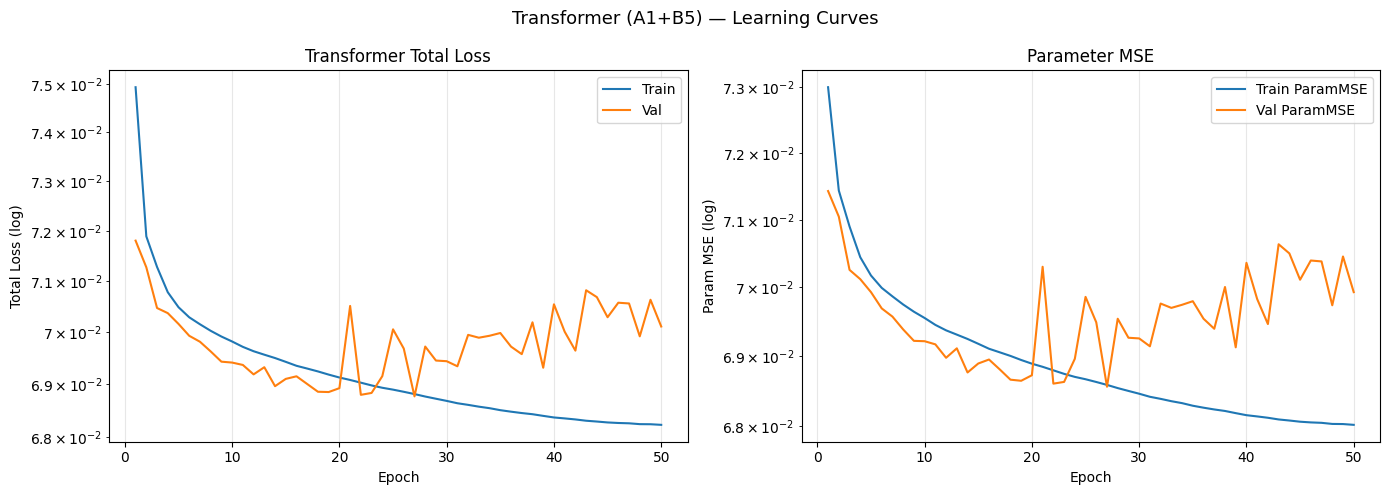

In [7]:
# ============================================================
# Cell 7 — Learning Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(range(1, EPOCHS+1), train_losses, label='Train')
ax1.semilogy(range(1, EPOCHS+1), val_losses,   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Total Loss (log)')
ax1.set_title('Transformer Total Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(range(1, EPOCHS+1), train_param, label='Train ParamMSE')
ax2.semilogy(range(1, EPOCHS+1), val_param,   label='Val ParamMSE')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Param MSE (log)')
ax2.set_title('Parameter MSE'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Transformer (A1+B5) — Learning Curves', fontsize=13)
plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# Cell 8 — Test Metrics via Surrogate
# ============================================================
model.eval()
all_spec_mse = []

with torch.no_grad():
    for spec_b, _ in test_loader:
        spec_b = spec_b.to(device)
        pred_params = model(spec_b)
        recon_spec  = surrogate(pred_params)
        mse = ((recon_spec - spec_b)**2).mean(dim=1)
        all_spec_mse.append(mse.cpu().numpy())

spec_mse_arr = np.concatenate(all_spec_mse)
print('═══════════════════════════════════════════')
print('  TEST METRICS — Transformer (A1+B5)')
print('═══════════════════════════════════════════')
print(f'  Mean spectral MSE   : {spec_mse_arr.mean():.6e}')
print(f'  Median spectral MSE : {np.median(spec_mse_arr):.6e}')
for p in [90, 95, 99]:
    print(f'  {p}th pctile MSE    : {np.percentile(spec_mse_arr, p):.6e}')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
  TEST METRICS — Transformer (A1+B5)
═══════════════════════════════════════════
  Mean spectral MSE   : 1.236718e-04
  Median spectral MSE : 5.774203e-05
  90th pctile MSE    : 2.285944e-04
  95th pctile MSE    : 3.411475e-04
  99th pctile MSE    : 1.362683e-03
═══════════════════════════════════════════


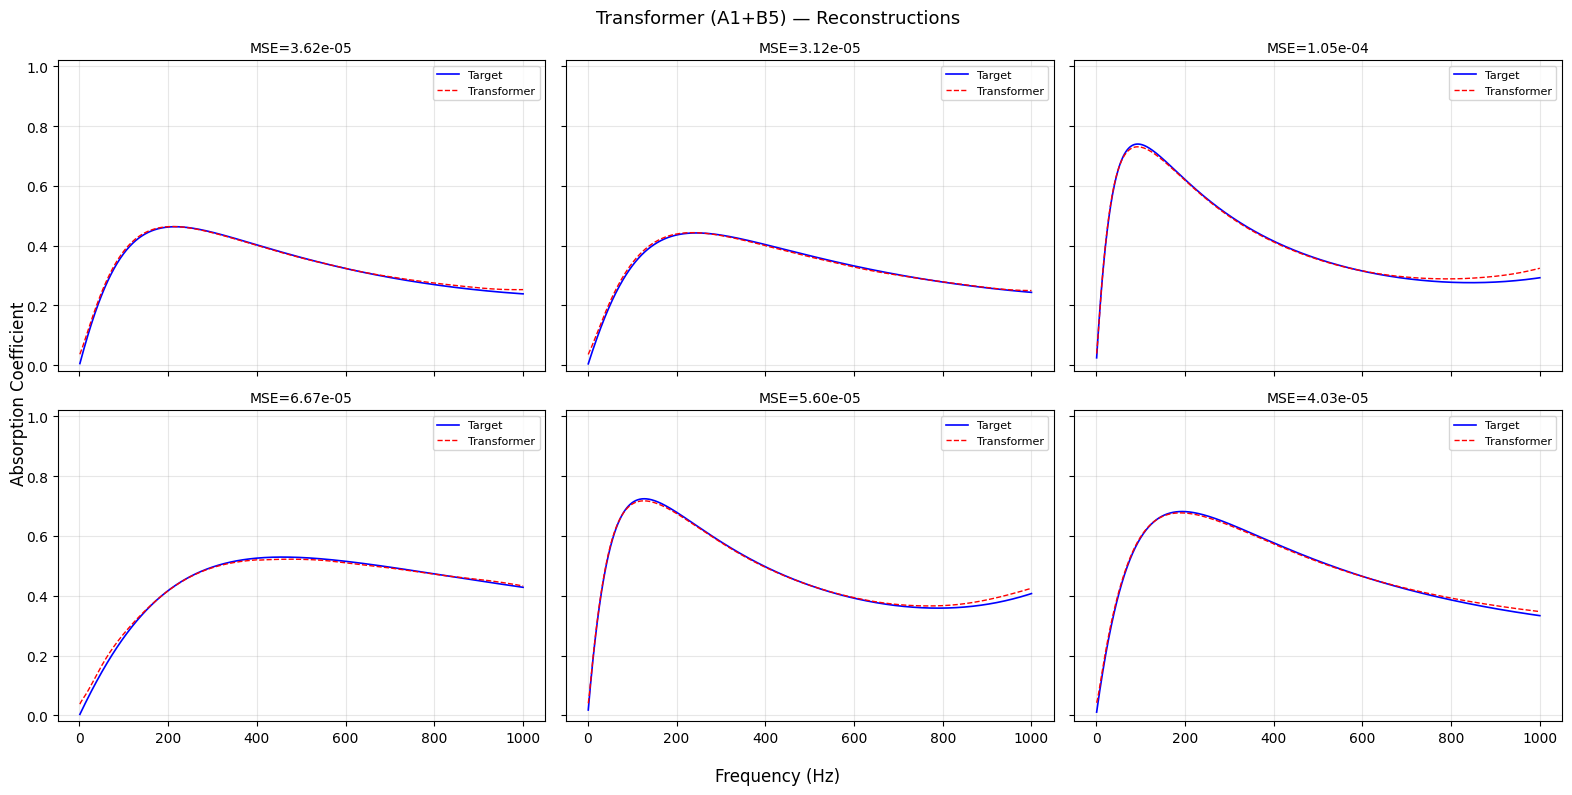

In [9]:
# ============================================================
# Cell 9 — Overlay: 6 Spectra
# ============================================================
np.random.seed(77)
show_idx = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
model.eval()
for ax, idx in zip(axes.flat, show_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        pred = model(spec_t)
        recon = surrogate(pred).cpu().numpy().flatten()
    mse = np.mean((recon - target)**2)

    ax.plot(frequencies, target, 'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, recon,  'r--', lw=1.0, label='Transformer')
    ax.set_title(f'MSE={mse:.2e}', fontsize=10)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('Transformer (A1+B5) — Reconstructions', fontsize=13)
plt.tight_layout(); plt.show()

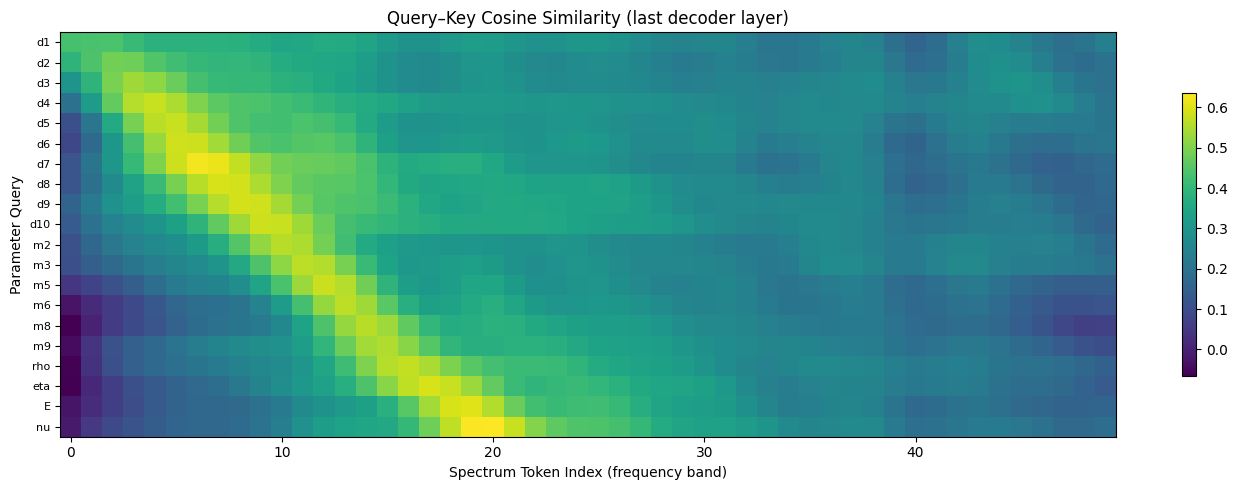

In [10]:
# ============================================================
# Cell 10 — Attention Visualisation (1 sample)
# ============================================================
# We'll hook into the last decoder layer's cross-attention weights
attn_weights = {}
def attn_hook(name):
    def hook_fn(module, args, output):
        # TransformerDecoderLayer returns output only; we use a custom approach
        attn_weights[name] = output
    return hook_fn

# Simpler: manually compute attention for one sample
model.eval()
idx = show_idx[0]
spec_t = torch.tensor(Y_test[idx], dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    tokens = model.tokenizer(spec_t)
    memory = model.encoder(tokens)
    queries = model.param_queries.expand(1, -1, -1)
    queries = model.query_pos(queries)

    # Last decoder layer cross-attention: Q from queries, K from memory
    last_dec = model.decoder.layers[-1]
    # Get Q, K for cross-attention
    # This is approximate; we just visualize cosine similarity
    Q = queries[0]  # (20, d_model)
    K = memory[0]   # (50, d_model)
    sim = F.cosine_similarity(Q.unsqueeze(1), K.unsqueeze(0), dim=-1)  # (20, 50)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(sim.cpu().numpy(), aspect='auto', cmap='viridis')
ax.set_xlabel('Spectrum Token Index (frequency band)')
ax.set_ylabel('Parameter Query')
ax.set_yticks(range(20))
ax.set_yticklabels(PARAM_NAMES, fontsize=8)
ax.set_title('Query–Key Cosine Similarity (last decoder layer)')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

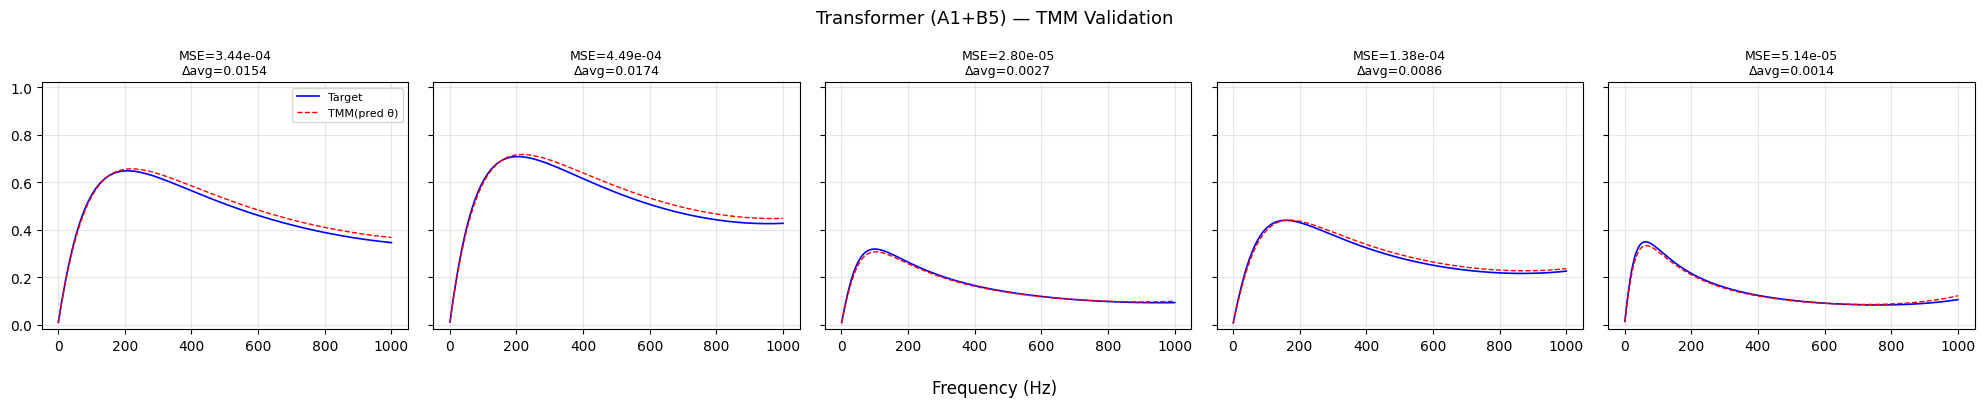


  TMM Validation:
    Sample  86155  MSE=3.4367e-04  Δavg=0.0154
    Sample  29633  MSE=4.4878e-04  Δavg=0.0174
    Sample  67710  MSE=2.8045e-05  Δavg=0.0027
    Sample  62348  MSE=1.3783e-04  Δavg=0.0086
    Sample  98787  MSE=5.1366e-05  Δavg=0.0014
  Mean TMM MSE: 2.0194e-04


In [11]:
# ============================================================
# Cell 11 — TMM Validation (5 samples)
# ============================================================
NUM_TMM = 5
np.random.seed(99)
tmm_idx = np.random.choice(len(X_test), NUM_TMM, replace=False)

fig, axes = plt.subplots(1, NUM_TMM, figsize=(20, 4), sharex=True, sharey=True)
tmm_results = []

for ax, idx in zip(axes, tmm_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        pred_n = model(spec_t).cpu().numpy().flatten()

    pred_raw = scaler_x.inverse_transform(pred_n.reshape(1, -1)).flatten()
    pred_raw = validate_and_clip_parameters(pred_raw.reshape(1, -1)).flatten()

    param_dict = {
        'rho': float(pred_raw[16]), 'eta': float(pred_raw[17]),
        'E': float(pred_raw[18]), 'nu': float(pred_raw[19]), 'W': 2000.0,
        'd': [float(pred_raw[i]) for i in range(10)],
        'm': {2: float(pred_raw[10]), 3: float(pred_raw[11]),
              5: float(pred_raw[12]), 6: float(pred_raw[13]),
              8: float(pred_raw[14]), 9: float(pred_raw[15])}
    }
    _, alpha_tmm, _, _ = calculate_acoustic_properties(param_dict)

    mse_tmm = np.mean((alpha_tmm - target)**2)
    avg_err = abs(alpha_tmm.mean() - target.mean())
    tmm_results.append({'idx': idx, 'mse': mse_tmm, 'avg_err': avg_err})

    ax.plot(frequencies, target,    'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, alpha_tmm, 'r--', lw=1.0, label='TMM(pred θ)')
    ax.set_title(f'MSE={mse_tmm:.2e}\nΔavg={avg_err:.4f}', fontsize=9)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    if idx == tmm_idx[0]: ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.suptitle('Transformer (A1+B5) — TMM Validation', fontsize=13)
plt.tight_layout(); plt.show()

print('\n  TMM Validation:')
for r in tmm_results:
    print(f'    Sample {r["idx"]:6d}  MSE={r["mse"]:.4e}  Δavg={r["avg_err"]:.4f}')
print(f'  Mean TMM MSE: {np.mean([r["mse"] for r in tmm_results]):.4e}')

In [12]:
# ============================================================
# Cell 12 — Save Model
# ============================================================
torch.save({
    'model_state_dict': model.state_dict(),
    'architecture': {
        'num_params': NUM_PARAMS, 'num_freq': NUM_FREQ,
        'token_len': TOKEN_LEN, 'd_model': D_MODEL, 'nhead': NHEAD,
        'num_enc': NUM_ENC_LAYERS, 'num_dec': NUM_DEC_LAYERS,
        'dim_ff': DIM_FF, 'dropout': DROPOUT,
    },
    'train_loss': train_losses, 'val_loss': val_losses,
    'best_val_loss': best_val,
    'surrogate_path': SURROGATE_PATH,
}, TRANS_PATH)

with open(TRANS_SCALER, 'wb') as f:
    pickle.dump(scaler_x, f)

print(f'✓ Model saved → {TRANS_PATH}  ({os.path.getsize(TRANS_PATH)/1e6:.1f} MB)')

✓ Model saved → ../models\inverse_transformer_a1.pth  (7.7 MB)


---
## Summary

| Metric | Value |
|--------|-------|
| Architecture | Transformer: 50 spectrum tokens → 4-layer enc → 4-layer dec → 20 queries |
| Loss | ParamMSE + 2.0 × Spectral MSE (through frozen surrogate) |
| Inference | Single deterministic forward pass |

**Key advantage:** Attention captures long-range spectral patterns; DETR-like structured output.  
**Limitation:** Deterministic — cannot express multi-modality without ensembles.